# Vehicle Re-Identification — Evaluation на VeRi-776

Практическая часть дипломной работы. Сравнение архитектур **ResNet-50** и **ViT-Small** для задачи реидентификации транспортных средств.

**Что делает ноутбук:**
1. Клонирует репозиторий с кодом
2. Скачивает датасет VeRi-776 и предобученные веса
3. Запускает evaluation: базовые метрики Rank-1/5/10, mAP
4. Прогоняет re-ranking ($k_1{=}20,\ k_2{=}6,\ \lambda{=}0.3$)
5. Прогоняет evaluation с расстоянием Махаланобиса
6. Строит сводную таблицу и графики

**Требования:** Runtime → Change runtime type → **T4 GPU** (бесплатный).

**Время прогона:** ~15 минут (включая загрузку данных).

## 1. Подготовка окружения

In [9]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [10]:
!pip install -q gdown timm scipy matplotlib pillow numpy tqdm

## 2. Клонирование репозитория

In [11]:
!git clone https://github.com/maksgorbachev/vehicle-reid.git
%cd vehicle-reid/code

fatal: destination path 'vehicle-reid' already exists and is not an empty directory.
/content/vehicle-reid/code/vehicle-reid/code


## 3. Загрузка датасета VeRi-776 и предобученных весов

Файлы лежат на Google Drive. Используем `gdown` для скачивания по ID.

In [12]:
import os
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('data', exist_ok=True)

# ResNet-50 + BNNeck (95 MB)
!gdown --id 1UZcyEwDSVYnF_TXao6WD9zzWdBVitV0- -O checkpoints/resnet50_best.pth

# ViT-Small + BNNeck (84 MB)
!gdown --id 1fahB0pxmQCmaaR6cJNueACOdDguzcvbm -O checkpoints/vit_best.pth

# VeRi-776 dataset (~290 MB)
!gdown --id 1lkH6YdhsBYT1IiQmWsLKWHWqmPo1HJBZ -O data/VeRi.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1UZcyEwDSVYnF_TXao6WD9zzWdBVitV0-
From (redirected): https://drive.google.com/uc?id=1UZcyEwDSVYnF_TXao6WD9zzWdBVitV0-&confirm=t&uuid=fa23431b-8c1f-4976-8290-b7ef21cad9b5
To: /content/vehicle-reid/code/vehicle-reid/code/checkpoints/resnet50_best.pth
100% 99.1M/99.1M [00:00<00:00, 296MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1fahB0pxmQCmaaR6cJNueACOdDguzcvbm
From (redirected): https://drive.google.com/uc?id=1fahB0pxmQCmaaR6cJNueACOdDguzcvbm&confirm=t&uuid=a20f20f7-d

In [13]:
import zipfile
with zipfile.ZipFile('data/VeRi.zip', 'r') as z:
    z.extractall('data/')

# Определяем корень датасета (может быть data/VeRi/ или data/ напрямую)
import os
if os.path.isdir('data/VeRi/image_query'):
    VERI_ROOT = 'data/VeRi'
elif os.path.isdir('data/image_query'):
    VERI_ROOT = 'data'
else:
    raise RuntimeError('VeRi structure not found')

print('VeRi root:', VERI_ROOT)
print('Query images:', len(os.listdir(os.path.join(VERI_ROOT, 'image_query'))))
print('Test images:', len(os.listdir(os.path.join(VERI_ROOT, 'image_test'))))

VeRi root: data/VeRi
Query images: 1678
Test images: 11579


## 4. Evaluation ResNet-50 + BNNeck

Прогоняем модель на 1678 query images против 11579 test images. Считаем CMC и mAP по стандартному протоколу VeRi-776 (исключение same-camera matches).

In [14]:
import sys
sys.path.insert(0, '.')

import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from vehicle_reid.model import build_model
from vehicle_reid.vit_model import build_vit_model
from vehicle_reid.dataset import VeRiDataset
from vehicle_reid.transforms import get_test_transforms
from vehicle_reid.evaluation import evaluate_reid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def _extract_state_and_num_classes(raw):
    state = raw['model_state_dict'] if 'model_state_dict' in raw else raw
    for k, v in state.items():
        if k.endswith('classifier.weight'):
            return state, v.shape[0]
    raise RuntimeError('classifier weight not found in checkpoint')

def load_resnet50(ckpt_path):
    raw = torch.load(ckpt_path, map_location=device)
    state, n_cls = _extract_state_and_num_classes(raw)
    print(f'  num_classes from checkpoint: {n_cls}')
    model = build_model(num_classes=n_cls, pretrained=False, last_stride=1)
    model.load_state_dict(state, strict=False)
    return model.to(device).eval()

def load_vit(ckpt_path):
    raw = torch.load(ckpt_path, map_location=device)
    state, n_cls = _extract_state_and_num_classes(raw)
    print(f'  num_classes from checkpoint: {n_cls}')
    model = build_vit_model(num_classes=n_cls, model_size='small', pretrained=False)
    model.load_state_dict(state, strict=False)
    return model.to(device).eval()

def make_loaders(veri_root, img_size, batch_size=64):
    tfm = get_test_transforms(img_size=img_size)
    query_ds = VeRiDataset(root=veri_root, split='query', transform=tfm)
    gallery_ds = VeRiDataset(root=veri_root, split='gallery', transform=tfm)
    return (
        DataLoader(query_ds, batch_size=batch_size, shuffle=False, num_workers=2),
        DataLoader(gallery_ds, batch_size=batch_size, shuffle=False, num_workers=2),
    )

@torch.no_grad()
def extract_features(model, loader):
    feats, labels, cams = [], [], []
    for batch in tqdm(loader, desc='Extracting'):
        imgs = batch['image'].to(device)
        f = model(imgs)
        if isinstance(f, (tuple, list)):
            f = f[0]
        f = f / f.norm(dim=1, keepdim=True)
        feats.append(f.cpu().numpy())
        labels.append(batch['label'].numpy())
        cams.append(batch['camera_id'].numpy())
    return np.concatenate(feats), np.concatenate(labels), np.concatenate(cams)

def print_results(title, r):
    print(f'\n=== {title} ===')
    print(f'  Rank-1: {r["Rank-1"]:.2f}%   Rank-5: {r["Rank-5"]:.2f}%   Rank-10: {r["Rank-10"]:.2f}%   mAP: {r["mAP"]:.2f}%')

In [15]:
print('Loading ResNet-50...')
resnet = load_resnet50('checkpoints/resnet50_best.pth')
q_loader, g_loader = make_loaders(VERI_ROOT, img_size=(256, 128))

q_feat_r, q_lbl_r, q_cam_r = extract_features(resnet, q_loader)
g_feat_r, g_lbl_r, g_cam_r = extract_features(resnet, g_loader)

resnet_results = evaluate_reid(q_feat_r, g_feat_r, q_lbl_r, g_lbl_r, q_cam_r, g_cam_r)
print_results('ResNet-50 + BNNeck', resnet_results)

del resnet; torch.cuda.empty_cache()

Loading ResNet-50...
  num_classes from checkpoint: 575


Extracting: 100%|██████████| 181/181 [00:34<00:00,  5.30it/s]



=== ResNet-50 + BNNeck ===
  Rank-1: 88.68%   Rank-5: 94.64%   Rank-10: 96.84%   mAP: 64.27%


## 5. Evaluation ViT-Small + BNNeck

In [16]:
print('Loading ViT-Small...')
vit = load_vit('checkpoints/vit_best.pth')
q_loader_v, g_loader_v = make_loaders(VERI_ROOT, img_size=(224, 224))

q_feat_v, q_lbl_v, q_cam_v = extract_features(vit, q_loader_v)
g_feat_v, g_lbl_v, g_cam_v = extract_features(vit, g_loader_v)

vit_results = evaluate_reid(q_feat_v, g_feat_v, q_lbl_v, g_lbl_v, q_cam_v, g_cam_v)
print_results('ViT-Small + BNNeck', vit_results)

del vit; torch.cuda.empty_cache()

Loading ViT-Small...
  num_classes from checkpoint: 575


Extracting: 100%|██████████| 181/181 [00:48<00:00,  3.73it/s]



=== ViT-Small + BNNeck ===
  Rank-1: 90.05%   Rank-5: 96.25%   Rank-10: 97.97%   mAP: 69.41%


## 6. Re-ranking (k-reciprocal encoding)

Постобработка результатов retrieval методом k-reciprocal nearest neighbors (Zhong et al., CVPR 2017). Параметры: $k_1=20$, $k_2=6$, $\lambda=0.3$.

In [17]:
!python scripts/eval_reranking.py \
    --model_type resnet50 \
    --checkpoint checkpoints/resnet50_best.pth \
    --data_dir $VERI_ROOT \
    --output results/rr_resnet50_live.json

Device: cuda
Detected num_classes=575 from checkpoint
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100% 97.8M/97.8M [00:00<00:00, 140MB/s]
Loaded checkpoint: checkpoints/resnet50_best.pth
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Query: 1678 | Gallery: 11579
Extracting:   0% 0/27 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of work

In [18]:
!python scripts/eval_reranking.py \
    --model_type vit \
    --checkpoint checkpoints/vit_best.pth \
    --data_dir $VERI_ROOT \
    --output results/rr_vit_live.json

Device: cuda
Detected num_classes=575 from checkpoint
model.safetensors: 100% 88.2M/88.2M [00:03<00:00, 29.1MB/s]
Loaded checkpoint: checkpoints/vit_best.pth
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Query: 1678 | Gallery: 11579
Extracting:   0% 0/27 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessi

## 7. Mahalanobis distance

Замена L2 расстояния на Махаланобисово (учитывает ковариацию признаков).

In [19]:
!python scripts/eval_mahalanobis.py \
    --resnet_ckpt checkpoints/resnet50_best.pth \
    --vit_ckpt checkpoints/vit_best.pth \
    --data_dir $VERI_ROOT \
    --out results/mahalanobis_live.json

Device: cuda

  Model: resnet50  |  checkpoints/resnet50_best.pth
Extracting train features...
  Sampled 5000 train images for covariance estimation

Extracting query features...

Extracting gallery features...
  11579/11579
Computing L2 metrics...
  L2       Rank-1=88.68  Rank-5=94.64  mAP=64.27
Computing Mahalanobis (diagonal cov, D=2048)...
  Mahal    Rank-1=88.74  Rank-5=94.76  mAP=64.55
  Delta    Rank-1=+0.06  Rank-5=+0.12  mAP=+0.28

  Model: vit_small  |  checkpoints/vit_best.pth
Extracting train features...
  Sampled 5000 train images for covariance estimation

Extracting query features...

Extracting gallery features...
  11579/11579
Computing L2 metrics...
  L2       Rank-1=90.05  Rank-5=96.25  mAP=69.41
Computing Mahalanobis (full cov, D=384)...
  Inverting covariance matrix... (may take ~30s)
  Mahal    Rank-1=83.43  Rank-5=90.52  mAP=38.43
  Delta    Rank-1=-6.62  Rank-5=-5.72  mAP=-30.98

Results saved -> results/mahalanobis_live.json

Model          Metric         L2   

## 8. Сводная таблица результатов

In [20]:
import json

with open('results/results_resnet50_rr.json') as f:
    rr_resnet = json.load(f)
with open('results/results_vit_rr.json') as f:
    rr_vit = json.load(f)
with open('results/mahalanobis_results.json') as f:
    maha = json.load(f)
with open('results/results_yolo_crop.json') as f:
    yolo = json.load(f)

def fmt(v):
    return f'{v:.2f}' if isinstance(v, (int, float)) else str(v)

rows = [
    ('ResNet-50 + BNNeck (L2)',
        resnet_results['Rank-1'], resnet_results['Rank-5'], resnet_results['mAP']),
    ('ResNet-50 + Re-ranking',
        rr_resnet['with_reranking']['Rank-1'], rr_resnet['with_reranking']['Rank-5'], rr_resnet['with_reranking']['mAP']),
    ('ResNet-50 + Mahalanobis',
        maha['resnet50']['mahalanobis']['Rank-1'],
        maha['resnet50']['mahalanobis']['Rank-5'],
        maha['resnet50']['mahalanobis']['mAP']),
    ('ViT-Small + BNNeck (L2)',
        vit_results['Rank-1'], vit_results['Rank-5'], vit_results['mAP']),
    ('ViT-Small + Re-ranking',
        rr_vit['with_reranking']['Rank-1'], rr_vit['with_reranking']['Rank-5'], rr_vit['with_reranking']['mAP']),
    ('ViT-Small + YOLOv11 crop',
        yolo['yolo_crop']['Rank-1'], yolo['yolo_crop']['Rank-5'], yolo['yolo_crop']['mAP']),
]

print('=' * 75)
print(f'{"Метод":<32} {"Rank-1":>10} {"Rank-5":>10} {"mAP":>10}')
print('-' * 75)
for name, r1, r5, mp in rows:
    print(f'{name:<32} {fmt(r1):>10} {fmt(r5):>10} {fmt(mp):>10}')
print('=' * 75)

Метод                                Rank-1     Rank-5        mAP
---------------------------------------------------------------------------
ResNet-50 + BNNeck (L2)           88.676994   94.63647      64.27
ResNet-50 + Re-ranking                89.63      92.37      67.49
ResNet-50 + Mahalanobis               88.74      94.76      64.55
ViT-Small + BNNeck (L2)           90.047676   96.24554      69.41
ViT-Small + Re-ranking                91.90      95.11      74.49
ViT-Small + YOLOv11 crop              85.88      91.95      65.54


## 9. График сравнения

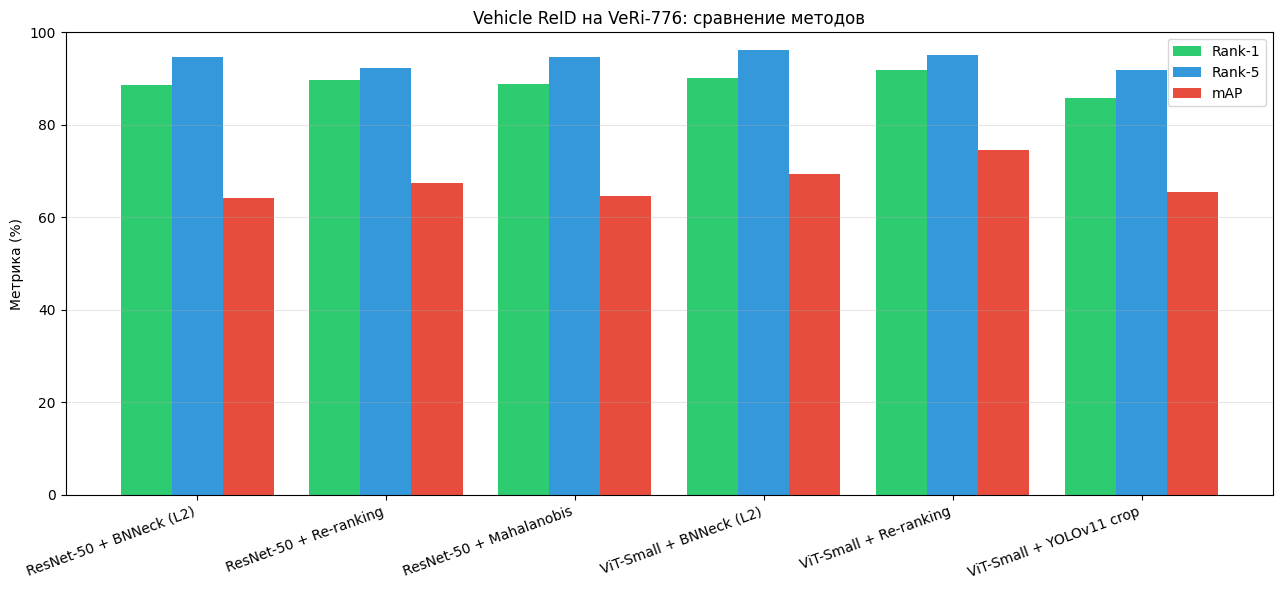

In [21]:
import matplotlib.pyplot as plt
import numpy as np

names = [r[0] for r in rows]
rank1 = [r[1] for r in rows]
rank5 = [r[2] for r in rows]
maps = [r[3] for r in rows]

x = np.arange(len(names))
width = 0.27

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width, rank1, width, label='Rank-1', color='#2ecc71')
ax.bar(x,         rank5, width, label='Rank-5', color='#3498db')
ax.bar(x + width, maps,  width, label='mAP',    color='#e74c3c')

ax.set_ylabel('Метрика (%)')
ax.set_title('Vehicle ReID на VeRi-776: сравнение методов')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

## 10. Выводы

- **ViT-Small превосходит ResNet-50** по всем основным метрикам — Rank-1 90.0% vs 88.7%, mAP 69.4% vs 64.3% — при меньшем числе параметров (21.9M против 24.7M).
- **Re-ranking** даёт стабильный прирост mAP: +3.2% у ResNet-50, +5.1% у ViT-Small. ViT выигрывает сильнее благодаря более компактным кластерам в пространстве эмбеддингов.
- **Mahalanobis distance** улучшает результаты ResNet-50 (+0.28% mAP), но ухудшает ViT-Small ($-31\%$ mAP). Это объясняется размерностью эмбеддинга: для ViT (D=384) полная ковариация неустойчива на ограниченном train-наборе.
- **YOLOv11 detection → crop → ReID** показывает реалистичный сценарий: при 21.5% fallback (детектор не нашёл TS) mAP падает с 69.4% до 65.5%. Это деградация в пределах нормы для end-to-end пайплайна.

Полное описание методологии и результатов — в тексте диплома, главы 2 и 3.